<a href="https://colab.research.google.com/github/Raveen-de-silva/My-Web/blob/main/MBI807B_Week3_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧪 MBI807B — Week 3 Lab
## From Raw Data to Actionable Insights with Python

**Course:** MBI807B — Business Intelligence and Data Warehousing  
**Lab duration:** ~35 minutes  
**Tools:** Google Colab (no installation required) + Python

---

### 🎯 What you will do in this lab

In the lecture, you learned the **Data-to-Insight pipeline**:

```
Raw Data → Processed Data → Information → Knowledge → Actionable Insights
```

In this lab, you will **walk through that entire pipeline in Python** — step by step — using a real e-commerce sales dataset.

By the end, you will have produced an **actionable business insight** from messy raw data.

---

### 💡 How to use this notebook

- Each section has **explanation cells** (like this one) followed by **code cells** (grey boxes)
- To run a code cell: click on it and press **`Shift + Enter`** (or click the ▶ button on the left)
- Cells must be run **in order** — top to bottom
- If you get lost, you can always re-run from the beginning
- 🔧 Cells marked with **EXERCISE** are yours to complete — they are short and guided

> **Note for self-study:** This notebook is fully self-contained. Every code cell is explained before and after. You can work through it at your own pace.

---
## 🌐 Google Colab — Quick Orientation

If this is your first time in Google Colab, here is what you need to know:

| Action | How |
|--------|-----|
| Run a cell | Click the cell → `Shift + Enter` |
| Run all cells | Menu → `Runtime` → `Run all` |
| Restart if something breaks | Menu → `Runtime` → `Restart and run all` |
| Save your work | `Ctrl + S` or `Cmd + S` — saves to your Google Drive |

Let's start with a simple test to confirm everything is working:

In [13]:
# ✅ Test cell — run this first
print("✅ Python is working!")
print("Welcome to MBI807B Week 3 Lab")

✅ Python is working!
Welcome to MBI807B Week 3 Lab


---
## 📦 BLOCK 0 — Import Libraries

Python uses **libraries** — collections of pre-built tools — so we do not have to write everything from scratch.

In data analysis, three libraries are essential:

| Library | What it does |
|---------|-------------|
| `pandas` | Load, clean, and transform data (like Excel, but programmable) |
| `matplotlib` | Create charts and visualisations |
| `seaborn` | Create more polished statistical visualisations |

We import them once at the beginning, and they are available for the rest of the notebook.

In [14]:
# Import the libraries we need
import pandas as pd                   # Data manipulation
import matplotlib.pyplot as plt       # Charts
import seaborn as sns                 # Nicer charts

# Display settings
sns.set_style("whitegrid")            # Chart style
pd.set_option('display.max_columns', 10)  # Show up to 10 columns

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


---
## 📂 BLOCK 1 — Load and Explore Raw Data

### 📍 Pipeline stage: RAW DATA

> *"Raw data is data in its original form — unprocessed, uncleaned, and often containing errors."*  
> — Week 3 Lecture

### About the dataset

We will work with **EcoShop Online Sales** — a simulated dataset based on real e-commerce patterns.  
It contains **500 sales transactions** from an online retailer operating across 7 countries in 2023.

Each row represents one transaction with the following columns:

| Column | Description |
|--------|-------------|
| `InvoiceID` | Unique transaction identifier |
| `InvoiceDate` | Date of transaction |
| `Country` | Country where the order was placed |
| `Category` | Product category |
| `SubCategory` | Product sub-category |
| `Quantity` | Number of units (negative = returns/cancellations) |
| `UnitPrice` | Price per unit in GBP |
| `CustomerID` | Unique customer identifier |

Let's load it and take a first look:

In [16]:
# Load the dataset
# The file 'ecommerce_sales.csv' should be in the same folder as this notebook
# In Google Colab: upload it using the 📁 Files icon on the left sidebar
from google.colab import files
uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded)))

#df = pd.read_csv('ecommerce_sales.csv')

print(f'✅ Dataset loaded')
print(f'   Rows: {df.shape[0]}')
print(f'   Columns: {df.shape[1]}')

Saving ecommerce_sales.csv to ecommerce_sales.csv
✅ Dataset loaded
   Rows: 500
   Columns: 8


> **What just happened?**  
> `pd.read_csv()` reads a CSV file and stores it as a **DataFrame** — a table with rows and columns, similar to an Excel spreadsheet.  
> We stored it in a variable called `df` (short for DataFrame — a common convention).

In [19]:
# Preview the first 5 rows
# This is always the first thing you do with a new dataset
df.head(6)

,InvoiceID,InvoiceDate,Country,Category,SubCategory,Quantity,UnitPrice,CustomerID
0,INV10000,11/27/2023,United Kingdom,Sports,Outdoor,8,121.74,C1458
1,INV10001,10/4/2023,United Kingdom,Books,Academic,2,NaN,C1160
2,INV10002,7/7/2023,Germany,Sports,Fitness,12,9.50,C1975
3,INV10003,10/1/2023,Australia,Home & Garden,Decor,3,172.69,C1387
4,INV10004,9/21/2023,Netherlands,Electronics,Phones,9,8.11,C1942
5,INV10005,4/16/2023,United Kingdom,Home & Garden,Kitchen,18,134.19,C1771


In [20]:
# Check data types of each column
# This tells us what kind of data each column holds
df.dtypes

,0
InvoiceID,object
InvoiceDate,object
Country,object
Category,object
SubCategory,object
Quantity,int64
UnitPrice,float64
CustomerID,object


In [21]:
# Statistical summary of numerical columns
# .describe() gives us count, mean, min, max, and percentiles
df.describe()

,Quantity,UnitPrice
count,500.00000,474.000000
mean,8.76800,103.689895
std,7.06158,56.081118
min,-19.00000,5.740000
25%,4.00000,55.030000
50%,9.00000,105.765000
75%,14.00000,150.667500
max,19.00000,199.340000


**🔍 Look at the output above and notice:**
- What is the minimum value in `Quantity`? Is that normal?
- What is the count for `UnitPrice`? Is it 500? Why might it be less?

These observations will guide our **data cleaning** in the next block.

---
## 🧹 BLOCK 2 — Data Quality Assessment & Cleaning

### 📍 Pipeline stage: PROCESSED DATA

> *"Transformation techniques are only as good as your input data quality."*  
> — Week 3 Lecture, Data Quality slide

Real-world data is **never perfect**. Before we can analyse anything, we need to identify and handle:

1. **Missing values** — empty cells with no data
2. **Invalid values** — data that is technically present but logically wrong (e.g., negative quantities)

### Step 2.1 — Detect missing values

In [22]:
# Count missing values per column
print("Missing values per column:")
print("="*35)
missing = df.isnull().sum()
print(missing)
print("="*35)
print(f"Total missing values: {missing.sum()}")
print(f"That is {missing.sum()/len(df)*100:.1f}% of all data points")

Missing values per column:
InvoiceID       0
InvoiceDate     0
Country         0
Category        0
SubCategory     0
Quantity        0
UnitPrice      26
CustomerID      0
dtype: int64
Total missing values: 26
That is 5.2% of all data points


> **Interpretation:**  
> The missing values in `UnitPrice` are a problem — we **cannot calculate revenue** without a price.  
> Our business decision: **remove rows where UnitPrice is missing** (they cannot contribute to analysis).

In [23]:
# Remove rows with missing UnitPrice
rows_before = len(df)
df = df.dropna(subset=['UnitPrice'])
rows_after = len(df)

print(f"Rows before cleaning: {rows_before}")
print(f"Rows removed:         {rows_before - rows_after}")
print(f"Rows remaining:       {rows_after}")

Rows before cleaning: 500
Rows removed:         26
Rows remaining:       474


### Step 2.2 — Detect and handle invalid values

In our dataset, **negative quantities** represent returns or cancellations.  
For a sales analysis, we want to focus only on completed purchases.

In [24]:
# Inspect negative quantity rows
returns = df[df['Quantity'] < 0]
print(f"Transactions with negative quantity (returns/cancellations): {len(returns)}")
print()
print("Sample of return transactions:")
returns.head(3)

Transactions with negative quantity (returns/cancellations): 25

Sample of return transactions:


,InvoiceID,InvoiceDate,Country,Category,SubCategory,Quantity,UnitPrice,CustomerID
8,INV10008,5/9/2023,United Kingdom,Sports,Outdoor,-15,37.23,C1647
15,INV10015,5/17/2023,United Kingdom,Electronics,Laptops,-13,172.84,C1317
18,INV10018,5/6/2023,Germany,Electronics,Accessories,-2,85.15,C1129


In [25]:
# Keep only valid sales (positive quantity)
df_clean = df[df['Quantity'] > 0].copy()

print(f"✅ Clean dataset: {len(df_clean)} valid transactions")
print(f"   Removed {len(df) - len(df_clean)} return/cancellation rows")

✅ Clean dataset: 449 valid transactions
   Removed 25 return/cancellation rows


---
### 🔧 EXERCISE 1 — Verify data quality (5 minutes)

After cleaning, we should verify that our dataset has **no remaining issues**.  
Complete the two lines of code below:

**Hint:** You already used both of these methods above!

In [28]:
# EXERCISE 1 — Complete the code below

# 1. Check if there are still any missing values in df_clean
print("Missing values after cleaning:")
print(df_clean.isnull().sum())       # ← replace ___ with the correct code

# 2. Confirm there are no more negative quantities
print("\nMinimum quantity value:")
print( df_clean['Quantity'].min())   # ← .min() or .max() ?

Missing values after cleaning:
InvoiceID      0
InvoiceDate    0
Country        0
Category       0
SubCategory    0
Quantity       0
UnitPrice      0
CustomerID     0
dtype: int64

Minimum quantity value:
1


<details>
<summary>💡 Click here to see the solution</summary>

```python
print(df_clean.isnull().sum())
print(df_clean['Quantity'].min())
```

</details>

---
## 🔄 BLOCK 3 — Data Transformation & Aggregation

### 📍 Pipeline stage: INFORMATION

> *"Aggregation converts detailed data into meaningful summaries."*  
> — Week 3 Lecture, Aggregation slide

Now that our data is clean, we can **enrich** it and **aggregate** it into meaningful summaries.

### Step 3.1 — Create a calculated field: Total Revenue

The dataset has `Quantity` and `UnitPrice` separately.  
We need to combine them to get the **revenue per transaction**.

In [29]:
# Create a new column: TotalRevenue = Quantity × UnitPrice
df_clean['TotalRevenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Preview the result
df_clean[['InvoiceID', 'Quantity', 'UnitPrice', 'TotalRevenue']].head(5)

,InvoiceID,Quantity,UnitPrice,TotalRevenue
0,INV10000,8,121.74,973.92
2,INV10002,12,9.50,114.00
3,INV10003,3,172.69,518.07
4,INV10004,9,8.11,72.99
5,INV10005,18,134.19,2415.42


### Step 3.2 — Aggregate by Country

We want to know: **which countries generate the most revenue?**

`.groupby()` is the pandas equivalent of a **GROUP BY** in SQL or a **PivotTable** in Excel.

In [30]:
# Aggregate total revenue by country
revenue_by_country = df_clean.groupby('Country')['TotalRevenue'].sum()

# Sort from highest to lowest
revenue_by_country = revenue_by_country.sort_values(ascending=False)

# Round for readability
revenue_by_country = revenue_by_country.round(2)

print("Total Revenue by Country (GBP):")
print("="*40)
print(revenue_by_country)

Total Revenue by Country (GBP):
Country
United Kingdom    225984.78
France             62873.30
Germany            62371.14
Spain              36392.33
Netherlands        29963.32
Belgium            23893.11
Australia          19212.02
Name: TotalRevenue, dtype: float64


### Step 3.3 — Aggregate by Category

Now let's look at **which product categories** are driving revenue.

In [31]:
# Aggregate by Category — multiple metrics at once
category_summary = df_clean.groupby('Category').agg(
    TotalRevenue   = ('TotalRevenue', 'sum'),
    Transactions   = ('InvoiceID', 'count'),
    AvgOrderValue  = ('TotalRevenue', 'mean')
).round(2).sort_values('TotalRevenue', ascending=False)

print("Revenue Summary by Category:")
category_summary

Revenue Summary by Category:


,TotalRevenue,Transactions,AvgOrderValue
Category,,,
Home & Garden,105156.97,104,1011.12
Clothing,96075.29,80,1200.94
Sports,94033.14,92,1022.10
Books,88581.68,98,903.89
Electronics,76842.92,75,1024.57


> 📌 **Note — Data Integration**  
> In this lab we work with a **single data source**. In a real business scenario, this sales dataset would typically be **joined** with other sources — for example, a customer profile table (CRM), a product catalogue, or regional demographic data. That process is called **Data Integration**, and it is one of the core transformation techniques covered in the Week 3 lecture.  
> Python handles this with `pd.merge()` — the equivalent of a JOIN in SQL or VLOOKUP in Excel.

---
### 🔧 EXERCISE 2 — Aggregate by Month (5 minutes)

We want to identify **seasonal trends** — which months had the highest revenue?  
This is a **temporal aggregation**, as covered in the lecture.

Complete the code below. The first step is done for you.

In [32]:
# EXERCISE 2 — Aggregate revenue by month

# Step 1: Convert InvoiceDate to datetime format (done for you)
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Step 2: Extract the month number into a new column
df_clean['Month'] = df_clean['InvoiceDate'].dt.month   # ← .month or .year ?

# Step 3: Group by Month and sum TotalRevenue
revenue_by_month = df_clean.groupby('Month')['TotalRevenue'].sum().round(2)  # ← which column?

print("Monthly Revenue:")
print(revenue_by_month)

Monthly Revenue:
Month
1     30243.13
2     42123.26
3     26550.09
4     31720.82
5     28950.58
6     48767.26
7     49794.09
8     42493.18
9     33743.33
10    40351.03
11    45026.52
12    40926.71
Name: TotalRevenue, dtype: float64


<details>
<summary>💡 Click here to see the solution</summary>

```python
df_clean['Month'] = df_clean['InvoiceDate'].dt.month
revenue_by_month = df_clean.groupby('Month')['TotalRevenue'].sum().round(2)
```

</details>

---
## 📊 BLOCK 4 — Visualisation

### 📍 Pipeline stage: KNOWLEDGE

> *"The goal is not just analysis — it's actionable business outcomes."*  
> — Week 3 Lecture, 5-Step Insight Generation Process

Numbers in a table are **information**. A well-designed chart transforms them into **knowledge** — patterns become visible, comparisons become clear.

In the next block, we will connect that knowledge to **business decisions**, completing the pipeline.

### Chart 1 — Revenue by Country

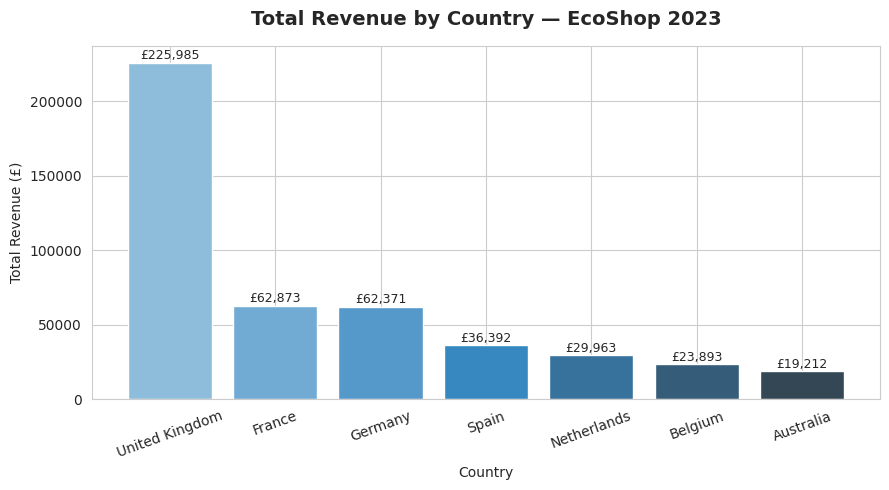

In [33]:
# Bar chart: Revenue by Country
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    revenue_by_country.index,
    revenue_by_country.values,
    color=sns.color_palette("Blues_d", len(revenue_by_country))
)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        height + 200,
        f'£{height:,.0f}',
        ha='center', va='bottom', fontsize=9
    )

ax.set_title('Total Revenue by Country — EcoShop 2023', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Country')
ax.set_ylabel('Total Revenue (£)')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

### Chart 2 — Revenue by Category

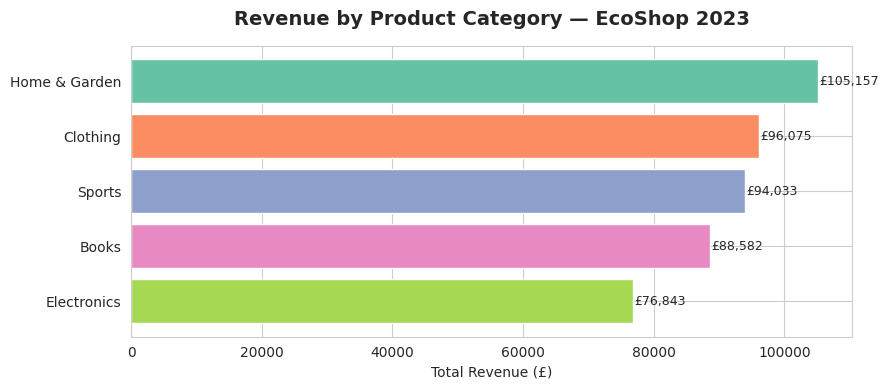

In [34]:
# Horizontal bar chart: Revenue by Category
fig, ax = plt.subplots(figsize=(9, 4))

colors = sns.color_palette("Set2", len(category_summary))
ax.barh(category_summary.index, category_summary['TotalRevenue'], color=colors)

# Add value labels
for i, (val, name) in enumerate(zip(category_summary['TotalRevenue'], category_summary.index)):
    ax.text(val + 200, i, f'£{val:,.0f}', va='center', fontsize=9)

ax.set_title('Revenue by Product Category — EcoShop 2023', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Revenue (£)')
ax.invert_yaxis()  # highest at top
plt.tight_layout()
plt.show()

### Chart 3 — Monthly Revenue Trend

This chart requires **Exercise 2** to be completed first.  
If you skipped it, go back and run Exercise 2 before continuing.

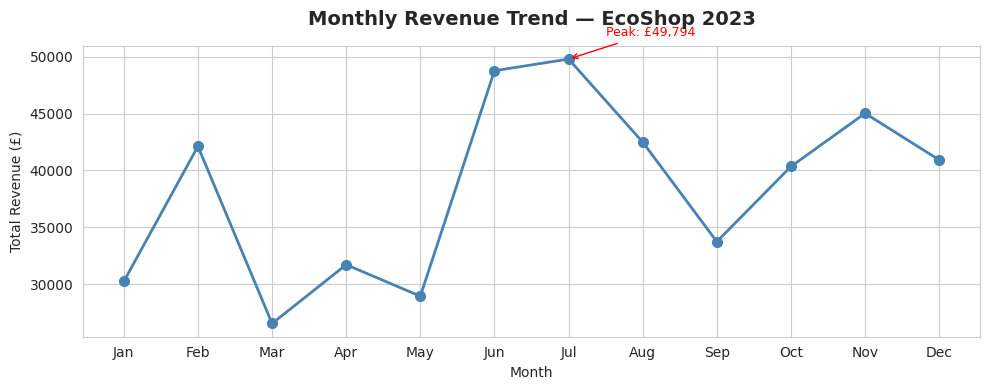

In [35]:
# Line chart: Monthly revenue trend
# Note: This cell requires Exercise 2 to be completed first.
# If revenue_by_month does not exist yet, complete Exercise 2 and re-run.

try:
    month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(
        revenue_by_month.index,
        revenue_by_month.values,
        marker='o', linewidth=2, color='steelblue', markersize=7
    )

    # Highlight peak month automatically
    peak_month = revenue_by_month.idxmax()
    peak_value = revenue_by_month.max()
    ax.annotate(
        f'Peak: £{peak_value:,.0f}',
        xy=(peak_month, peak_value),
        xytext=(peak_month + 0.5, peak_value + 2000),
        fontsize=9,
        arrowprops=dict(arrowstyle='->', color='red'),
        color='red'
    )

    ax.set_title('Monthly Revenue Trend — EcoShop 2023', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Month')
    ax.set_ylabel('Total Revenue (£)')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_names)
    plt.tight_layout()
    plt.show()

except NameError:
    print("⚠️  revenue_by_month not found.")
    print("   Please complete Exercise 2 first, then re-run this cell.")

---
## 💡 BLOCK 5 — From Insight to Business Decision

### 📍 Pipeline stage: ACTIONABLE INSIGHTS

Data analysis is only valuable when it **drives a decision**.  
Let's summarise what we found and translate it into business language.

The cell below generates an **automated insight summary** based on our analysis:

In [37]:
# Automated business insight summary
top_country       = revenue_by_country.index[0]
top_country_rev   = revenue_by_country.iloc[0]
top_country_share = top_country_rev / revenue_by_country.sum() * 100

top_category      = category_summary.index[0]
top_cat_rev       = category_summary['TotalRevenue'].iloc[0]
top_cat_avg       = category_summary['AvgOrderValue'].iloc[0]

bottom_category   = category_summary.index[-1]
bottom_cat_rev    = category_summary['TotalRevenue'].iloc[-1]

total_revenue     = df_clean['TotalRevenue'].sum()
total_orders      = len(df_clean)
avg_order_value   = total_revenue / total_orders

print("="*60)
print("  📊 ECOSHOP 2023 — EXECUTIVE INSIGHT SUMMARY")
print("="*60)
print(f"\n📦 Dataset: {total_orders} valid transactions analysed")
print(f"💰 Total Revenue: £{total_revenue:,.2f}")
print(f"🛒 Average Order Value: £{avg_order_value:,.2f}")
print()
print("─"*60)
print("🌍 GEOGRAPHIC INSIGHT")
print("─"*60)
print(f"  → {top_country} is the top market, generating")
print(f"    £{top_country_rev:,.2f} ({top_country_share:.1f}% of total revenue)")
print(f"  ✅ Action: Prioritise marketing budget in {top_country}")
print(f"     and investigate growth potential in smaller markets.")
print()
print("─"*60)
print("📦 PRODUCT INSIGHT")
print("─"*60)
print(f"  → {top_category} is the highest-revenue category")
print(f"    (£{top_cat_rev:,.2f} total, avg order £{top_cat_avg:,.2f})")
print(f"  → {bottom_category} generates the least revenue (£{bottom_cat_rev:,.2f})")
print(f"  ✅ Action: Expand {top_category} product range.")
print(f"     Review {bottom_category} pricing and promotion strategy.")
print()
print("─"*60)
print("📅 SEASONAL INSIGHT")
print("─"*60)
peak_month_name = month_names[revenue_by_month.idxmax() - 1]
low_month_name  = month_names[revenue_by_month.idxmin() - 1]
print(f"  → Peak revenue month: {peak_month_name} (£{revenue_by_month.max():,.2f})")
print(f"  → Lowest revenue month: {low_month_name} (£{revenue_by_month.min():,.2f})")
print(f"  ✅ Action: Increase inventory and ads before {peak_month_name}.")
print(f"     Run promotions in {low_month_name} to reduce seasonal dip.")
print()
print("="*60)
print("  Pipeline completed: Raw Data → Actionable Insights ✅")
print("="*60)

  📊 ECOSHOP 2023 — EXECUTIVE INSIGHT SUMMARY

📦 Dataset: 449 valid transactions analysed
💰 Total Revenue: £460,690.00
🛒 Average Order Value: £1,026.04

────────────────────────────────────────────────────────────
🌍 GEOGRAPHIC INSIGHT
────────────────────────────────────────────────────────────
  → United Kingdom is the top market, generating
    £225,984.78 (49.1% of total revenue)
  ✅ Action: Prioritise marketing budget in United Kingdom
     and investigate growth potential in smaller markets.

────────────────────────────────────────────────────────────
📦 PRODUCT INSIGHT
────────────────────────────────────────────────────────────
  → Home & Garden is the highest-revenue category
    (£105,156.97 total, avg order £1,011.12)
  → Electronics generates the least revenue (£76,842.92)
  ✅ Action: Expand Home & Garden product range.
     Review Electronics pricing and promotion strategy.

────────────────────────────────────────────────────────────
📅 SEASONAL INSIGHT
─────────────────────

---
## 🔁 BLOCK 6 — Reflection: Python vs Power BI

You have now completed the **full data-to-insight pipeline** in Python.  
The same pipeline you saw in the lecture — but in code.

Here is how Python and Power BI **complement** each other:

| Task | Power BI | Python |
|------|----------|--------|
| Load data | ✅ Drag & drop | ✅ One line of code |
| Clean data | ✅ Power Query (visual) | ✅ Explicit, documented, reproducible |
| Aggregate | ✅ Drag to pivot | ✅ `.groupby()` |
| Visualise | ✅ Interactive dashboards | ✅ Custom, publication-ready charts |
| Machine Learning | ❌ Limited | ✅ Full ML capabilities |
| Automation | ❌ Manual refresh | ✅ Fully scriptable pipelines |
| Cross-platform | ❌ Windows only | ✅ Mac, Windows, Linux, browser |
| Reproducibility | ⚠️ Hard to audit | ✅ Every step documented in code |

### Key message

> **Power BI is excellent for interactive exploration and dashboards.**  
> **Python is essential when you need automation, ML, or full control of your transformation logic.**  
> In professional practice, you will use **both**.

---

## 📝 Summary — What you did today

| Block | Action | Pipeline Stage |
|-------|--------|----------------|
| 1 | Loaded and explored raw data | Raw Data |
| 2 | Detected and removed missing + invalid values | Processed Data |
| 3 | Created calculated fields and aggregated by country, category, month | Information |
| 4 | Built visualisations from the aggregated data | Knowledge |
| 5 | Translated findings into business recommendations | Actionable Insights |

---

## 🚀 Going Further (Optional — for self-study)

If you want to explore beyond this lab, try these extensions:

1. **Which subcategory has the highest average order value?**  
   Hint: `groupby('SubCategory')` and `.mean()`

2. **How many unique customers does each country have?**  
   Hint: `.groupby('Country')['CustomerID'].nunique()`

3. **Create a chart showing revenue by both Category and Country**  
   Hint: `groupby(['Country', 'Category'])` then `.unstack()` and `.plot(kind='bar')`

import matplotlib.pyplot as plt
---

*Lab prepared for MBI807B Week 3 — Business Intelligence and Data Warehousing*  
*Dataset: EcoShop Online Sales 2023 (simulated, based on real e-commerce patterns)*

In [39]:
# 1. Which subcategory has the highest average order value?
avg_order_value = df_clean.groupby('SubCategory')['TotalRevenue'].mean().round(2)

highest_subcategory = avg_order_value.sort_values(ascending=False).head(1)

print("Subcategory with highest average order value:")
print(highest_subcategory)

Subcategory with highest average order value:
SubCategory
Womens Wear    1330.43
Name: TotalRevenue, dtype: float64


In [41]:
#2. How many unique customers does each country have?
unique_customers_by_country = df_clean.groupby('Country')['CustomerID'].nunique()

print("Unique customers per country:")
print(unique_customers_by_country)

Unique customers per country:
Country
Australia          21
Belgium            22
France             54
Germany            57
Netherlands        33
Spain              37
United Kingdom    199
Name: CustomerID, dtype: int64


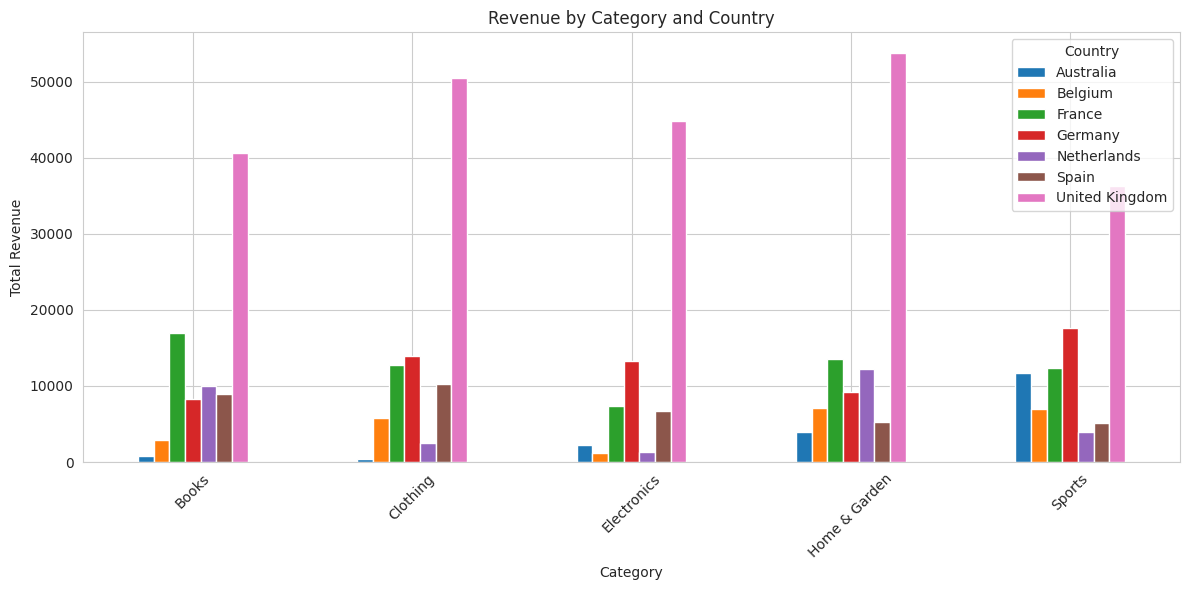

In [42]:
#3. Create a chart showing revenue by both Category and Country
import matplotlib.pyplot as plt

# Step 1: Aggregate revenue by Category and Country
revenue_cat_country = df_clean.groupby(['Category', 'Country'])['TotalRevenue'].sum().unstack()

# Step 2: Plot chart
revenue_cat_country.plot(kind='bar', figsize=(12,6))

# Step 3: Styling
plt.title('Revenue by Category and Country')
plt.xlabel('Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.legend(title='Country')

plt.tight_layout()
plt.show()